# BRISC U-Net Inference Notebook
Use this notebook after training to load a saved checkpoint and run prediction on **5 images** with their ground-truth masks and model predictions.


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import os
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [31]:
!find "/content/drive/MyDrive" -maxdepth 6 -type d | sed -n '1,200p'

/content/drive/MyDrive
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Colab Notebooks/lime
/content/drive/MyDrive/Colab Notebooks/lime/__pycache__
/content/drive/MyDrive/Colab Notebooks/lime/data
/content/drive/MyDrive/Colab Notebooks/INM705-CW
/content/drive/MyDrive/Colab Notebooks/INM705-CW/data
/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task
/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task/test
/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task/test/images
/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task/test/masks
/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task/train
/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task/train/images
/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task/train/masks
/content/drive/MyDrive/Colab Notebooks/INM705-CW/checkpoints
/content/drive/MyDrive/Colab Notebooks/INM705-CW/checkpoints/b

In [35]:
CHECKPOINT_PATH = "/content/drive/MyDrive/Colab Notebooks/INM705-CW/checkpoints/baseline/unet_baseline.pt"

INPUT_IMAGES_DIR = "/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task/test/images"
INPUT_MASKS_DIR = "/content/drive/MyDrive/Colab Notebooks/INM705-CW/data/segmentation_task/test/masks"

NUM_IMAGES = 5
RANDOM_SEED = 42

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/INM705-CW/inference_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [36]:
def denormalize_image(image):
    image = (image * 0.5) + 0.5
    return torch.clamp(image, 0.0, 1.0)

def mask_to_image(mask):
    mask_u8 = (mask.squeeze(0).cpu().numpy() > 0.5).astype(np.uint8) * 255
    return Image.fromarray(mask_u8)

def save_prediction_overlay(image, mask_gt, mask_pred, output_path):
    image_np = denormalize_image(image).permute(1, 2, 0).cpu().numpy()
    gt_np = (mask_gt.squeeze(0).cpu().numpy() > 0.5).astype(np.uint8)
    pred_np = (mask_pred.squeeze(0).cpu().numpy() > 0.5).astype(np.uint8)

    overlay = image_np.copy()
    overlay[gt_np == 1, 1] = np.clip(overlay[gt_np == 1, 1] + 0.5, 0, 1)
    overlay[pred_np == 1, 0] = np.clip(overlay[pred_np == 1, 0] + 0.5, 0, 1)

    out = (overlay * 255).astype(np.uint8)
    Image.fromarray(out).save(output_path)

In [37]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=32):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8

        self.enc1 = DoubleConv(in_channels, c1)
        self.enc2 = DoubleConv(c1, c2)
        self.enc3 = DoubleConv(c2, c3)
        self.enc4 = DoubleConv(c3, c4)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(c4, c4 * 2)

        self.up4 = nn.ConvTranspose2d(c4 * 2, c4, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(c4 * 2, c4)
        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c3 * 2, c3)
        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c2 * 2, c2)
        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c1 * 2, c1)
        self.out_conv = nn.Conv2d(c1, out_channels, kernel_size=1)

    def resize_to_match(self, src, target):
        if src.shape[-2:] == target.shape[-2:]:
            return src
        return F.interpolate(src, size=target.shape[-2:], mode="bilinear", align_corners=False)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([self.resize_to_match(d4, e4), e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([self.resize_to_match(d3, e3), e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([self.resize_to_match(d2, e2), e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([self.resize_to_match(d1, e1), e1], dim=1))

        return self.out_conv(d1)

In [38]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
image_size = checkpoint.get("image_size", 256)
base_channels = checkpoint.get("base_channels", 32)

model = UNet(in_channels=3, out_channels=1, base_channels=base_channels).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded checkpoint.")
print("image_size =", image_size)
print("base_channels =", base_channels)

Loaded checkpoint.
image_size = 256
base_channels = 32


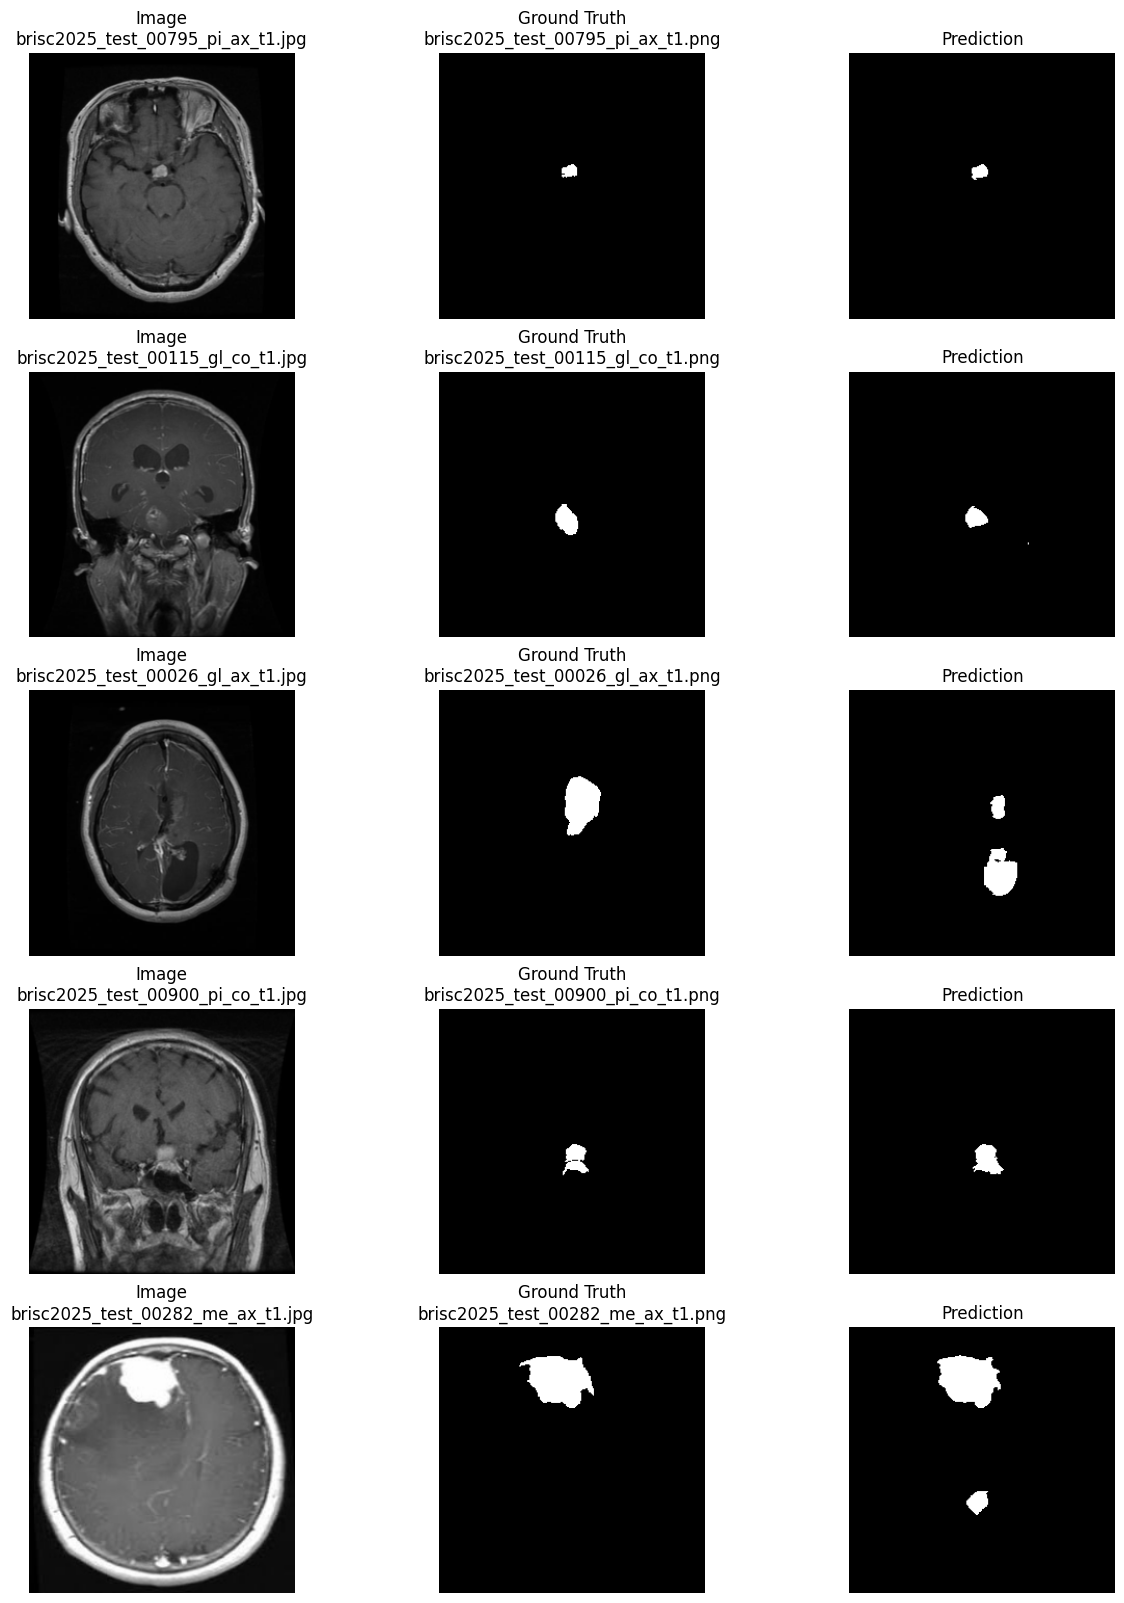

In [40]:
random.seed(RANDOM_SEED)

valid_exts = {".png", ".jpg"}

image_paths = sorted([
    p for p in Path(INPUT_IMAGES_DIR).iterdir()
    if p.is_file() and p.suffix.lower() in valid_exts
])

if len(image_paths) == 0:
    raise FileNotFoundError(f"No images found in {INPUT_IMAGES_DIR}")
num_to_show = min(NUM_IMAGES, len(image_paths))
sampled_images = random.sample(image_paths, num_to_show)

fig, axes = plt.subplots(num_to_show, 3, figsize=(15, 4 * num_to_show))

if num_to_show == 1:
    axes = [axes]

model.eval()
valid_mask_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

for i, image_path in enumerate(sampled_images):
    image_stem = image_path.stem
    candidate_masks = [
        p for p in Path(INPUT_MASKS_DIR).iterdir()
        if p.is_file() and p.stem == image_stem and p.suffix.lower() in valid_mask_exts
    ]

    if len(candidate_masks) == 0:
        raise FileNotFoundError(f"Ground-truth mask not found for {image_path.name}")

    mask_path = candidate_masks[0]

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    image_resized = TF.resize(image, [image_size, image_size], interpolation=InterpolationMode.BILINEAR)
    mask_resized = TF.resize(mask, [image_size, image_size], interpolation=InterpolationMode.NEAREST)

    image_tensor = TF.to_tensor(image_resized)
    image_tensor_norm = TF.normalize(
        image_tensor.clone(),
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor_norm)
        pred_mask = (torch.sigmoid(logits)[0] > 0.5).float().cpu().squeeze(0)

    gt_mask = (TF.to_tensor(mask_resized) > 0.5).float().squeeze(0)

    axes[i][0].imshow(image_resized)
    axes[i][0].set_title(f"Image\n{image_path.name}")
    axes[i][0].axis("off")

    axes[i][1].imshow(gt_mask, cmap="gray")
    axes[i][1].set_title(f"Ground Truth\n{mask_path.name}")
    axes[i][1].axis("off")

    axes[i][2].imshow(pred_mask, cmap="gray")
    axes[i][2].set_title("Prediction")
    axes[i][2].axis("off")

In [41]:
for item in results:
    print(item["name"])
    print("  prediction:", item["pred_save_path"])
    print("  overlay   :", item["overlay_save_path"])


In [42]:
fig, axes = plt.subplots(len(results), 3, figsize=(15, 4 * len(results)))

if len(results) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, item in enumerate(results):
    axes[i, 0].imshow(item["image_tensor"].permute(1, 2, 0))
    axes[i, 0].set_title(f"Image\n{item['name']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(item["gt_tensor"].squeeze(0), cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(item["pred_mask"].squeeze(0), cmap="gray")
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1500x0 with 0 Axes>